# 01 - Exploratory Data Analysis

Goal: Understand the Home Credit application dataset before building any model.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.shape

(307511, 122)

The dataset has many rows and features, so I want to first understand the target, missing values, and a few important variables before modeling.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [13]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [15]:
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

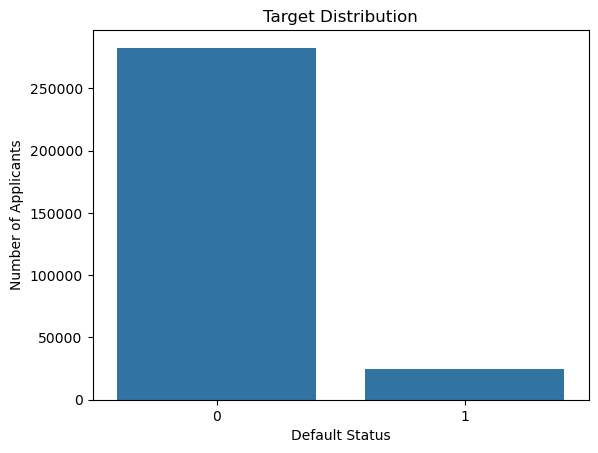

In [17]:
sns.countplot(x="TARGET", data=df)
plt.title("Target Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Applicants")
plt.show()

The target is highly imbalanced. Most applicants did not default. Because of this, accuracy alone will not be a good model metric later.

In [20]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
dtype: float64

In [22]:
high_missing = missing[missing > 0.50]
high_missing.shape[0]

41

Some columns have more than 50% missing values. I should avoid blindly filling these values because that may add noise or create misleading patterns.

In [25]:
df[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED
count,3.075110e+05,3.075110e+05,307499.000000,307511.000000,307511.000000
mean,1.687979e+05,5.990260e+05,27108.573909,-16036.995067,63815.045904
std,2.371231e+05,4.024908e+05,14493.737315,4363.988632,141275.766519
min,2.565000e+04,4.500000e+04,1615.500000,-25229.000000,-17912.000000
25%,1.125000e+05,2.700000e+05,16524.000000,-19682.000000,-2760.000000
50%,1.471500e+05,5.135310e+05,24903.000000,-15750.000000,-1213.000000
75%,2.025000e+05,8.086500e+05,34596.000000,-12413.000000,-289.000000
max,1.170000e+08,4.050000e+06,258025.500000,-7489.000000,365243.000000


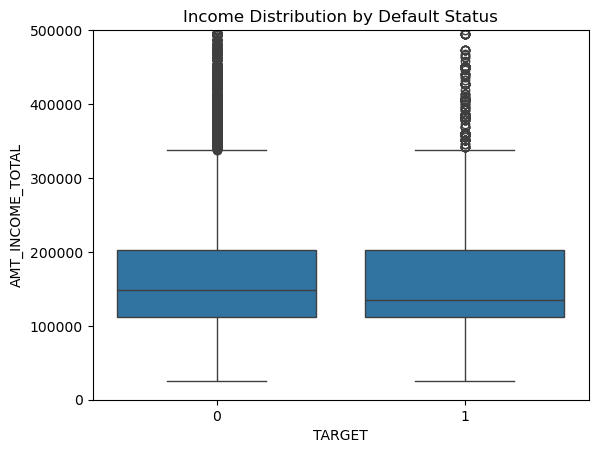

In [27]:
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df)
plt.title("Income Distribution by Default Status")
plt.ylim(0, 500000)
plt.show()

Income alone does not clearly separate defaulters from non-defaulters. It may still be useful when combined with other features.

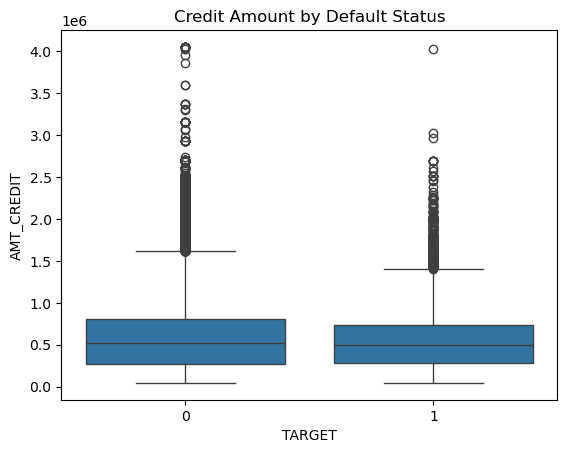

In [30]:
sns.boxplot(x="TARGET", y="AMT_CREDIT", data=df)
plt.title("Credit Amount by Default Status")
plt.show()

In [32]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365
df["AGE_YEARS"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

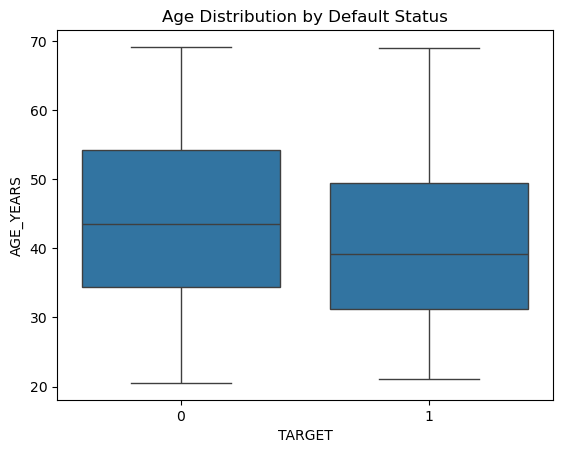

In [34]:
sns.boxplot(x="TARGET", y="AGE_YEARS", data=df)
plt.title("Age Distribution by Default Status")
plt.show()

Age seems more useful than raw DAYS_BIRTH because it is easier to interpret. I converted it into years for clearer analysis.

In [37]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df[ext_cols + ["TARGET"]].corr()["TARGET"].sort_values()

EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
TARGET          1.000000
Name: TARGET, dtype: float64

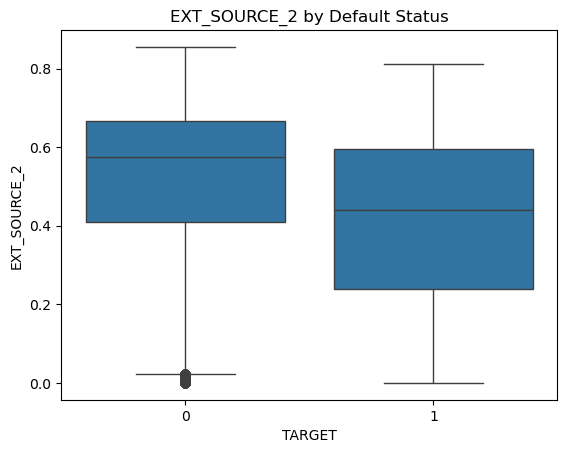

In [39]:
sns.boxplot(x="TARGET", y="EXT_SOURCE_2", data=df)
plt.title("EXT_SOURCE_2 by Default Status")
plt.show()

EXT_SOURCE features appear to have a stronger relationship with default risk than basic income fields. These may become important predictors in the model.

In [42]:
df["NAME_CONTRACT_TYPE"].value_counts(normalize=True)

NAME_CONTRACT_TYPE
Cash loans         0.904787
Revolving loans    0.095213
Name: proportion, dtype: float64

In [44]:
pd.crosstab(df["NAME_CONTRACT_TYPE"], df["TARGET"], normalize="index")

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,0.916541,0.083459
Revolving loans,0.945217,0.054783


## Initial EDA Summary

Key observations:
- The dataset is imbalanced, so accuracy should not be the main evaluation metric.
- Several features have high missing values and need careful treatment.
- Income alone does not strongly separate default and non-default groups.
- Age is easier to interpret after converting DAYS_BIRTH into years.
- EXT_SOURCE features appear to be useful predictors and should be included in modeling.

Next step:
Build a simple baseline model before trying more complex algorithms.